# DRUHÁ PREDIKCE - Typ poruchy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Načtení datasetu
df = pd.read_csv("../data/ML/Predictive_Dataset.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp")
# Kontrola dat
df.head()

,timestamp,machine_id,temperature,vibration,pressure,load,ambient_temperature,is_running,produced_units,defective_units,...,rolling_vibration_std_24h,rolling_pressure_mean_24h,rolling_pressure_std_24h,running_ratio_24h,hours_since_last_failure,failure_count_last_7d,failure_count_last_30d,target_failure_72h,target_failure_type,target_RUL_hours
0,2022-01-01,1,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1617.0
78843,2022-01-01,4,49.3,2.28,4.61,89.27,17.8,1,73,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1296.0
105124,2022-01-01,5,49.3,2.28,4.61,89.27,17.8,1,120,2,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1818.0
131405,2022-01-01,6,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1110.0
26281,2022-01-01,2,49.3,2.28,4.61,89.27,17.8,1,97,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,1242.0


In [2]:
# Namapování názvů linek vůči ID
machine_map = {
    1: "L1 - Řezací stanice",
    2: "L1 - Lis",
    3: "L1 - Montážní stanice",
    4: "L1 - Testovací stanice",
    5: "L2 - Řezací stanice",
    6: "L2 - Lis",
    7: "L2 - Montážní stanice",
    8: "L2 - Testovací stanice",
    9: "L3 - Řezací stanice",
    10: "L3 - Lis",
    11: "L3 - Montážní stanice",
    12: "L3 - Testovací stanice"
}

In [3]:
# Výběr pouze záznamů, kde je porucha do 72h
df_type = df[df["target_failure_72h"] == 1].copy()

df_type["hours_since_last_failure"] = df_type["hours_since_last_failure"].fillna(df_type["machine_age_hours"])

features = df_type.columns.drop([
    "timestamp",
    "machine_id",
    "target_failure_72h",
    "target_failure_type",
    "target_RUL_hours",
    "health_index",
    "produced_units",
    "defective_units",
]).tolist()

df_type.shape

(31248, 27)

In [4]:
df_type = df_type.dropna(subset=features)
df_type = df_type.reset_index(drop=True)

df_type.isnull().sum()

timestamp                            0
machine_id                           0
temperature                          0
vibration                            0
pressure                             0
load                                 0
ambient_temperature                  0
is_running                           0
produced_units                       0
defective_units                      0
operating_hours_since_maintenance    0
machine_age_hours                    0
health_index                         0
health_delta_24h                     0
rolling_temp_mean_24h                0
rolling_temp_std_24h                 0
rolling_vibration_mean_24h           0
rolling_vibration_std_24h            0
rolling_pressure_mean_24h            0
rolling_pressure_std_24h             0
running_ratio_24h                    0
hours_since_last_failure             0
failure_count_last_7d                0
failure_count_last_30d               0
target_failure_72h                   0
target_failure_type      

In [5]:
df_type.shape

(31248, 27)

In [6]:
# Počet záznamů poruch dle typu
df_type["target_failure_type"].value_counts()

target_failure_type
mechanical     9360
overheating    8424
pressure       7632
electrical     5832
Name: count, dtype: int64

In [7]:
# Rozdělení dat dle času (model se učí na starých datech a testuje na nových)
# Seřazení dat
df_type = df_type.sort_values("timestamp")

split_time = df_type["timestamp"].quantile(0.8)

# Split podle času
train = df_type[df_type["timestamp"] < split_time]
test = df_type[df_type["timestamp"] >= split_time]

# Vytvoření X a y
X_train = train[features]
y_train = train["target_failure_type"]

X_test = test[features]
y_test = test["target_failure_type"]

In [8]:
# Logistická regrese
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

In [9]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [10]:
# Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

model_gb = HistGradientBoostingClassifier(max_depth=5, random_state=42)

model_gb.fit(X_train, y_train)

pred_gb = model_gb.predict(X_test)

In [11]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr))

print("\n=== Random Forest ===")
print(classification_report(y_test, pred_rf))

print("\n=== Gradient Boosting ===")
print(classification_report(y_test, pred_gb))

=== Logistic Regression ===
              precision    recall  f1-score   support

  electrical       0.41      0.76      0.53      1224
  mechanical       0.36      0.39      0.37      1872
 overheating       0.28      0.31      0.29      1427
    pressure       0.41      0.09      0.14      1728

    accuracy                           0.36      6251
   macro avg       0.36      0.39      0.34      6251
weighted avg       0.36      0.36      0.32      6251


=== Random Forest ===
              precision    recall  f1-score   support

  electrical       0.30      0.26      0.28      1224
  mechanical       0.39      0.39      0.39      1872
 overheating       0.31      0.41      0.35      1427
    pressure       0.52      0.41      0.46      1728

    accuracy                           0.38      6251
   macro avg       0.38      0.37      0.37      6251
weighted avg       0.39      0.38      0.38      6251


=== Gradient Boosting ===
              precision    recall  f1-score   suppor

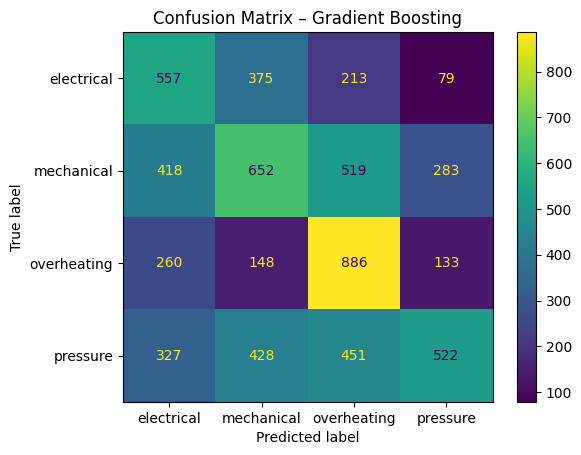

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_gb)

plt.title("Confusion Matrix – Gradient Boosting")
plt.show()

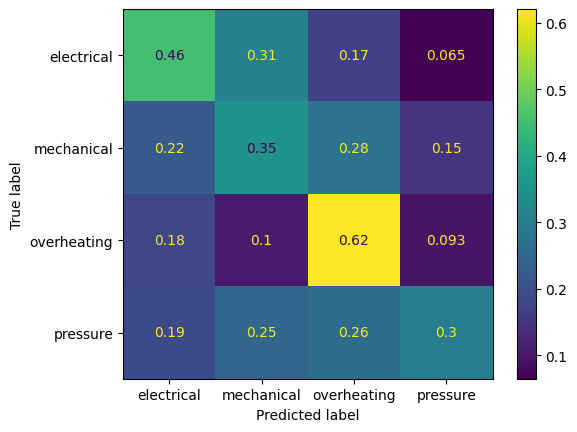

In [13]:
# Gradient Boosting - Confusion MAtrix - %
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_gb,
    normalize="true"
)

In [14]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, pred_gb)

0.43158056559236274

In [15]:
import pandas as pd

importances = model_rf.feature_importances_

feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

feat_importance.head(10)

machine_age_hours                    0.258607
hours_since_last_failure             0.134864
operating_hours_since_maintenance    0.127303
rolling_temp_mean_24h                0.111534
health_delta_24h                     0.100166
rolling_vibration_mean_24h           0.066918
ambient_temperature                  0.049322
rolling_pressure_mean_24h            0.042178
rolling_temp_std_24h                 0.024375
rolling_vibration_std_24h            0.024234
dtype: float64

=== XGBoost ===
              precision    recall  f1-score   support

  electrical       0.33      0.40      0.36      1224
  mechanical       0.46      0.39      0.42      1872
 overheating       0.39      0.57      0.47      1427
    pressure       0.56      0.36      0.44      1728

    accuracy                           0.42      6251
   macro avg       0.44      0.43      0.42      6251
weighted avg       0.45      0.42      0.42      6251

Balanced accuracy: 0.4294544615986208


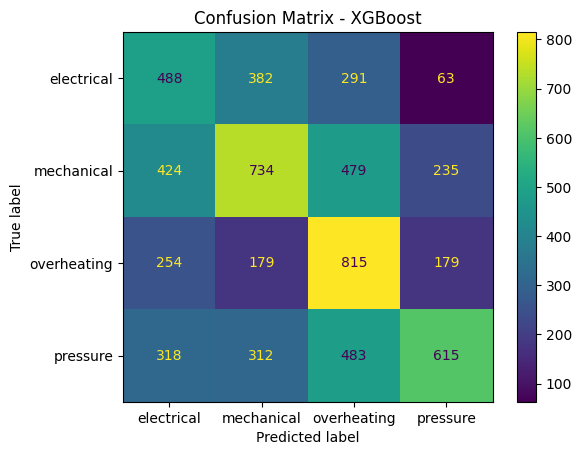

In [16]:
# XGBoost Test
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, classification_report
from xgboost import XGBClassifier

classes = sorted(y_train.unique())
label_to_int = {label: idx for idx, label in enumerate(classes)}
int_to_label = {idx: label for label, idx in label_to_int.items()}

y_train_xgb = y_train.map(label_to_int)

model_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model_xgb.fit(X_train, y_train_xgb)

pred_xgb_encoded = model_xgb.predict(X_test)
pred_xgb = pd.Series(pred_xgb_encoded, index=y_test.index).map(int_to_label)

print("=== XGBoost ===")
print(classification_report(y_test, pred_xgb))
print("Balanced accuracy:", balanced_accuracy_score(y_test, pred_xgb))

ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.show()


XGBoost nevyšel lépe než GB. Pouze se přehoupli váhy, které typy poruch dokáže predikovat lépe, ale je to jen Trade-Off. GB pořád lepší.

## Jednoduche porovnání základních modelů a doaldění Gradient Boostingu


In [17]:
# Pomocne funkce pro jednoduche porovnani modelu
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def build_gb_model(**kwargs):
    params = {
        "max_depth": 5,
        "random_state": 42,
    }
    params.update(kwargs)
    return HistGradientBoostingClassifier(**params)


In [18]:
# Srovnani puvodnich modelu na hold-out testu
holdout_summary = pd.DataFrame([
    {"model": "Logistic Regression", **evaluate_predictions(y_test, pred_lr)},
    {"model": "Random Forest", **evaluate_predictions(y_test, pred_rf)},
    {"model": "Gradient Boosting", **evaluate_predictions(y_test, pred_gb)},
    {"model": "XGBoost", **evaluate_predictions(y_test, pred_xgb)},
]).round(3).sort_values(["macro_f1", "balanced_accuracy"], ascending=False).reset_index(drop=True)

holdout_summary


,model,accuracy,macro_f1,balanced_accuracy
0,XGBoost,0.424,0.421,0.429
1,Gradient Boosting,0.419,0.416,0.432
2,Random Forest,0.376,0.370,0.370
3,Logistic Regression,0.360,0.335,0.386


In [19]:
# Jednoduche ladeni HistGradientBoosting
gb_candidates = [
    {"model": "GB baseline", "max_depth": 5, "learning_rate": 0.10, "max_iter": 100},
    {"model": "GB slower learning", "max_depth": 5, "learning_rate": 0.05, "max_iter": 200},
    {"model": "GB deeper", "max_depth": 8, "learning_rate": 0.05, "max_iter": 200},
    {"model": "GB shallower", "max_depth": 4, "learning_rate": 0.05, "max_iter": 300},
]

gb_models = {}
gb_tuning_rows = []

for cfg in gb_candidates:
    model = build_gb_model(
        max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"],
        max_iter=cfg["max_iter"],
    )
    model.fit(X_train, y_train)
    pred = pd.Series(model.predict(X_test), index=y_test.index)
    gb_models[cfg["model"]] = {"model": model, "pred": pred, "config": cfg}
    gb_tuning_rows.append({
        **cfg,
        **evaluate_predictions(y_test, pred),
    })

gb_tuning_results = (
    pd.DataFrame(gb_tuning_rows)
    .round(3)
    .sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

gb_tuning_results


,model,max_depth,learning_rate,max_iter,accuracy,macro_f1,balanced_accuracy
0,GB slower learning,5,0.05,200,0.429,0.427,0.439
1,GB baseline,5,0.10,100,0.419,0.416,0.432
2,GB deeper,8,0.05,200,0.416,0.413,0.423
3,GB shallower,4,0.05,300,0.369,0.365,0.374


GB Slower learning vyšel nejlépe

In [20]:
# Finalni porovnani: puvodni GB, nejlepsi doladeny GB a XGBoost
best_gb_name = gb_tuning_results.iloc[0]["model"]

final_candidates = {
    "Gradient Boosting": pd.Series(pred_gb, index=y_test.index),
    best_gb_name: gb_models[best_gb_name]["pred"],
    "XGBoost": pd.Series(pred_xgb, index=y_test.index),
}

final_comparison = pd.DataFrame([
    {"model": name, **evaluate_predictions(y_test, pred)}
    for name, pred in final_candidates.items()
]).round(3).sort_values(["macro_f1", "balanced_accuracy"], ascending=False).reset_index(drop=True)

display(final_comparison)

best_model_name = final_comparison.iloc[0]["model"]
best_model_pred = final_candidates[best_model_name]

print(f"Nejlepsi model podle macro F1: {best_model_name}")


,model,accuracy,macro_f1,balanced_accuracy
0,GB slower learning,0.429,0.427,0.439
1,XGBoost,0.424,0.421,0.429
2,Gradient Boosting,0.419,0.416,0.432


Nejlepsi model podle macro F1: GB slower learning


              precision    recall  f1-score   support

  electrical       0.34      0.45      0.39      1224
  mechanical       0.45      0.37      0.41      1872
 overheating       0.41      0.59      0.48      1427
    pressure       0.55      0.35      0.43      1728

    accuracy                           0.43      6251
   macro avg       0.44      0.44      0.43      6251
weighted avg       0.45      0.43      0.43      6251



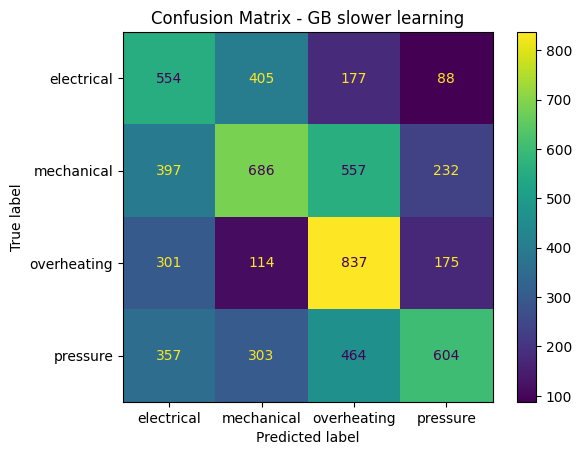

In [21]:
# Finalni vyhodnoceni nejlepsi varianty
print(classification_report(y_test, best_model_pred))

ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


In [22]:
best_gb_model = gb_models[best_gb_name]["model"]
best_gb_pred = gb_models[best_gb_name]["pred"]


In [23]:
# Test Gratient Boosting bet časových proměnných
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# definice "časových" features
time_features = [
    "machine_age_hours",
    "hours_since_last_failure",
    "operating_hours_since_maintenance"
]

# nové features BEZ těchto sloupců
features_no_time = [f for f in features if f not in time_features]

# vytvoření datasetu
X_train_no_time = train[features_no_time]
X_test_no_time = test[features_no_time]

y_train = train["target_failure_type"]
y_test = test["target_failure_type"]

# model (stejný jako hlavní!)
model_gb_no_time = HistGradientBoostingClassifier(random_state=42)

model_gb_no_time.fit(X_train_no_time, y_train)

pred_gb_no_time = model_gb_no_time.predict(X_test_no_time)

# výstupy
print("=== Gradient Boosting (FULL FEATURES) ===")
print(classification_report(y_test, pred_gb))

print("\n=== Gradient Boosting (WITHOUT TIME FEATURES) ===")
print(classification_report(y_test, pred_gb_no_time))

=== Gradient Boosting (FULL FEATURES) ===
              precision    recall  f1-score   support

  electrical       0.36      0.46      0.40      1224
  mechanical       0.41      0.35      0.38      1872
 overheating       0.43      0.62      0.51      1427
    pressure       0.51      0.30      0.38      1728

    accuracy                           0.42      6251
   macro avg       0.43      0.43      0.42      6251
weighted avg       0.43      0.42      0.41      6251


=== Gradient Boosting (WITHOUT TIME FEATURES) ===
              precision    recall  f1-score   support

  electrical       0.30      0.26      0.28      1224
  mechanical       0.34      0.37      0.35      1872
 overheating       0.29      0.36      0.32      1427
    pressure       0.25      0.19      0.21      1728

    accuracy                           0.30      6251
   macro avg       0.29      0.30      0.29      6251
weighted avg       0.29      0.30      0.29      6251



Bez časových features se model výrazně zhorší

In [24]:
# Načtení výstupu z první predikce s informacích o stroji, které mohou mít poruchu do 72h
failure_72h_results = pd.read_csv("failure_predictions.csv")

# Nalezení a získání daných strojů
risk_machines = failure_72h_results[
    failure_72h_results["Failure Prediction (0/1)"] == 1
].copy()

risk_machine_ids = risk_machines["Machine ID"].tolist()

# Získání a úprava dat pro druhou predikci typu poruchy
df_type_inference = df.copy()
df_type_inference["hours_since_last_failure"] = df_type_inference["hours_since_last_failure"].fillna(
    df_type_inference["machine_age_hours"]
)
df_type_inference = df_type_inference.dropna(subset=features).copy()

# Vybereme pouze záznamy pro stroje získané z první predikce
latest_type_input = (
    df_type_inference[df_type_inference["machine_id"].isin(risk_machine_ids)]
    .sort_values("timestamp")
    .groupby("machine_id")
    .tail(1)
    .copy()
)

latest_type_input[["machine_id", "timestamp"]]


,machine_id,timestamp
289090,11,2024-12-31
26280,1,2024-12-31
315371,12,2024-12-31


In [25]:
# Predikce typu poruchy pouze pro stroje označené v první predikci
type_probs = best_gb_model.predict_proba(latest_type_input[features])
type_pred = best_gb_model.predict(latest_type_input[features])

type_results = latest_type_input[["machine_id"]].copy()
type_results["predicted_type"] = type_pred
type_results["type_confidence"] = type_probs.max(axis=1)
type_results["Type Confidence (%)"] = (type_results["type_confidence"] * 100).round(1)

final_table_type = risk_machines.merge(
    type_results,
    left_on="Machine ID",
    right_on="machine_id",
    how="left"
)

final_table_type = final_table_type[[
    "Machine ID",
    "Machine Name",
    "Failure Prediction (YES/NO)",
    "Failure Probability (%)",
    "Risk Level",
    "predicted_type",
    "Type Confidence (%)",
]].rename(columns={
    "predicted_type": "Predicted Failure Type"
})

final_table_type = final_table_type.sort_values(
    ["Failure Probability (%)", "Type Confidence (%)"],
    ascending=False
).reset_index(drop=True)

final_table_type.to_csv("failure_type_predictions.csv", index=False)
final_table_type


,Machine ID,Machine Name,Failure Prediction (YES/NO),Failure Probability (%),Risk Level,Predicted Failure Type,Type Confidence (%)
0,1,L1 - Řezací stanice,YES,77.1,🔴 HIGH,mechanical,35.4
1,12,L3 - Testovací stanice,YES,71.9,🔴 HIGH,electrical,95.0
2,11,L3 - Montážní stanice,YES,50.9,🟠 MEDIUM,mechanical,59.7
